# Fit st and fpt with uncertainties in their slopes and breakpoint  
- Use this to find uncertainties in early slopes of FPT and ST fit  
- Then do T test to compare it with early slope of FN  

In [20]:
import numpy as np
import pandas as pd
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
from tes.commAnalysis import CommPercentages
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr, linregress 
from scipy.optimize import curve_fit
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from matplotlib import cm
from pathlib import Path
import os
import glob
import networkx as nx
import pwlf
import pickle
import umap

In [21]:
algo_umap = UmapAlgo()
algo= AlgoParFull()
analyse= AnalysisFunc()
reader = DataRead()
comm_ops = CommPercentages()
utils = DataUtils()

..\..\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


Piecewise linear fit define function 

In [33]:
data_folder = Path('../../data/results/calculate_final_params')
files=glob.glob(f"{data_folder}/final_*.pkl")
print(files)

['..\\..\\data\\results\\calculate_final_params\\final_bla.pkl', '..\\..\\data\\results\\calculate_final_params\\final_enti.pkl', '..\\..\\data\\results\\calculate_final_params\\final_fn.pkl', '..\\..\\data\\results\\calculate_final_params\\final_lha.pkl', '..\\..\\data\\results\\calculate_final_params\\final_lsc.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mob.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mop.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mos.pkl', '..\\..\\data\\results\\calculate_final_params\\final_mrn.pkl', '..\\..\\data\\results\\calculate_final_params\\final_orb.pkl', '..\\..\\data\\results\\calculate_final_params\\final_peri.pkl', '..\\..\\data\\results\\calculate_final_params\\final_pir.pkl', '..\\..\\data\\results\\calculate_final_params\\final_re.pkl']


In [34]:
def fit_piecewiseLinear(data, ax, label):
    # intervals as this is the time when state changes from another state
    
    intervals = data.copy()
    # print(f'original values: {intervals}')
    intervals = np.sort(intervals)
    n = len(intervals)

    # CCDF: P(T > t)
    ccdf = 1.0 - np.arange(1, n + 1) / n

    # Remove zero values (log undefined)
    mask = ccdf > 0
    intervals = intervals[mask]
    ccdf = ccdf[mask]

    # Log of CCDF
    log_ccdf = np.log(ccdf)

    x = intervals
    y = log_ccdf

    # Fit piecewise linear model with 2 segments
    my_pwlf = pwlf.PiecewiseLinFit(x, y)
    res = my_pwlf.fit(2)

    # Breakpoints returned by pwlf.fit
    breakpoints = res   # e.g. [min_x, breakpoint, max_x]

    # First segment is between breakpoints[0] and breakpoints[1]
    # finding out interval values which contributed to slope 1
    mask_slope1 = (x >= breakpoints[0]) & (x <= breakpoints[1])
    entries_slope1 = x[mask_slope1]

    # print("Entries belonging to slope 1:", entries_slope1.tolist())
     # Entries corresponding to slope 2 (between res[1] and res[2])
    mask2 = (x >= res[1]) & (x <= res[2])
    entries_slope2 = x[mask2]

    # Predict
    y_hat = my_pwlf.predict(x)

    # Plot
    ax.scatter(x, y, label="Data")
    ax.plot(x, y_hat, 'r', label="Piecewise fit")
    ax.set_ylabel("log P(T > t)")
    ax.set_title(f"Log-CCDF breakpoint ~ {round(res[1])} {label}")
    ax.legend()

    # Slopes of the fitted lines
    slopes = my_pwlf.calc_slopes()
    se_betas=my_pwlf.standard_errors()
    

    print("Slopes of fitted lines:", slopes)
    print("SE for early slopes",se_betas[1])

    # Optionally annotate slopes on the plot
    for i, slope in enumerate(slopes):
        ax.text(x.mean(), y_hat.mean() - i*0.5, f"Slope {i+1}: {slope:.3f}", color="blue")

    return {'exp':slopes, 'joint': round(res[1]),'slope_1_entries':entries_slope1.tolist(),'s2':entries_slope2.tolist(),'s1_se':se_betas[1]}


### part fpt

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
Slopes of fitted lines: [-0.00279662 -0.0167166 ]
SE for early slopes 0.00013334431293590465
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
Slopes of fitted lines: [-0.00406944 -0.0409144 ]
SE for early slopes 7.654333264540138e-05
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
Slopes of fitted lines: [-0.00428918 -0.03345481]
SE for early slopes 6.273173374448883e-05
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
Slopes of fitted lines: [-0.00400736 -0.04824635]
SE for early slopes 0.00013386561466056764
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
Slopes of fitted lines: [-0.00473713 -0.05207649]
SE for early slopes 6.773179291787054e-05
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
Slopes of fitted lines: [-0.00383098 -0.02368937]
SE for early slopes 7.89659272214103e-05
Processin

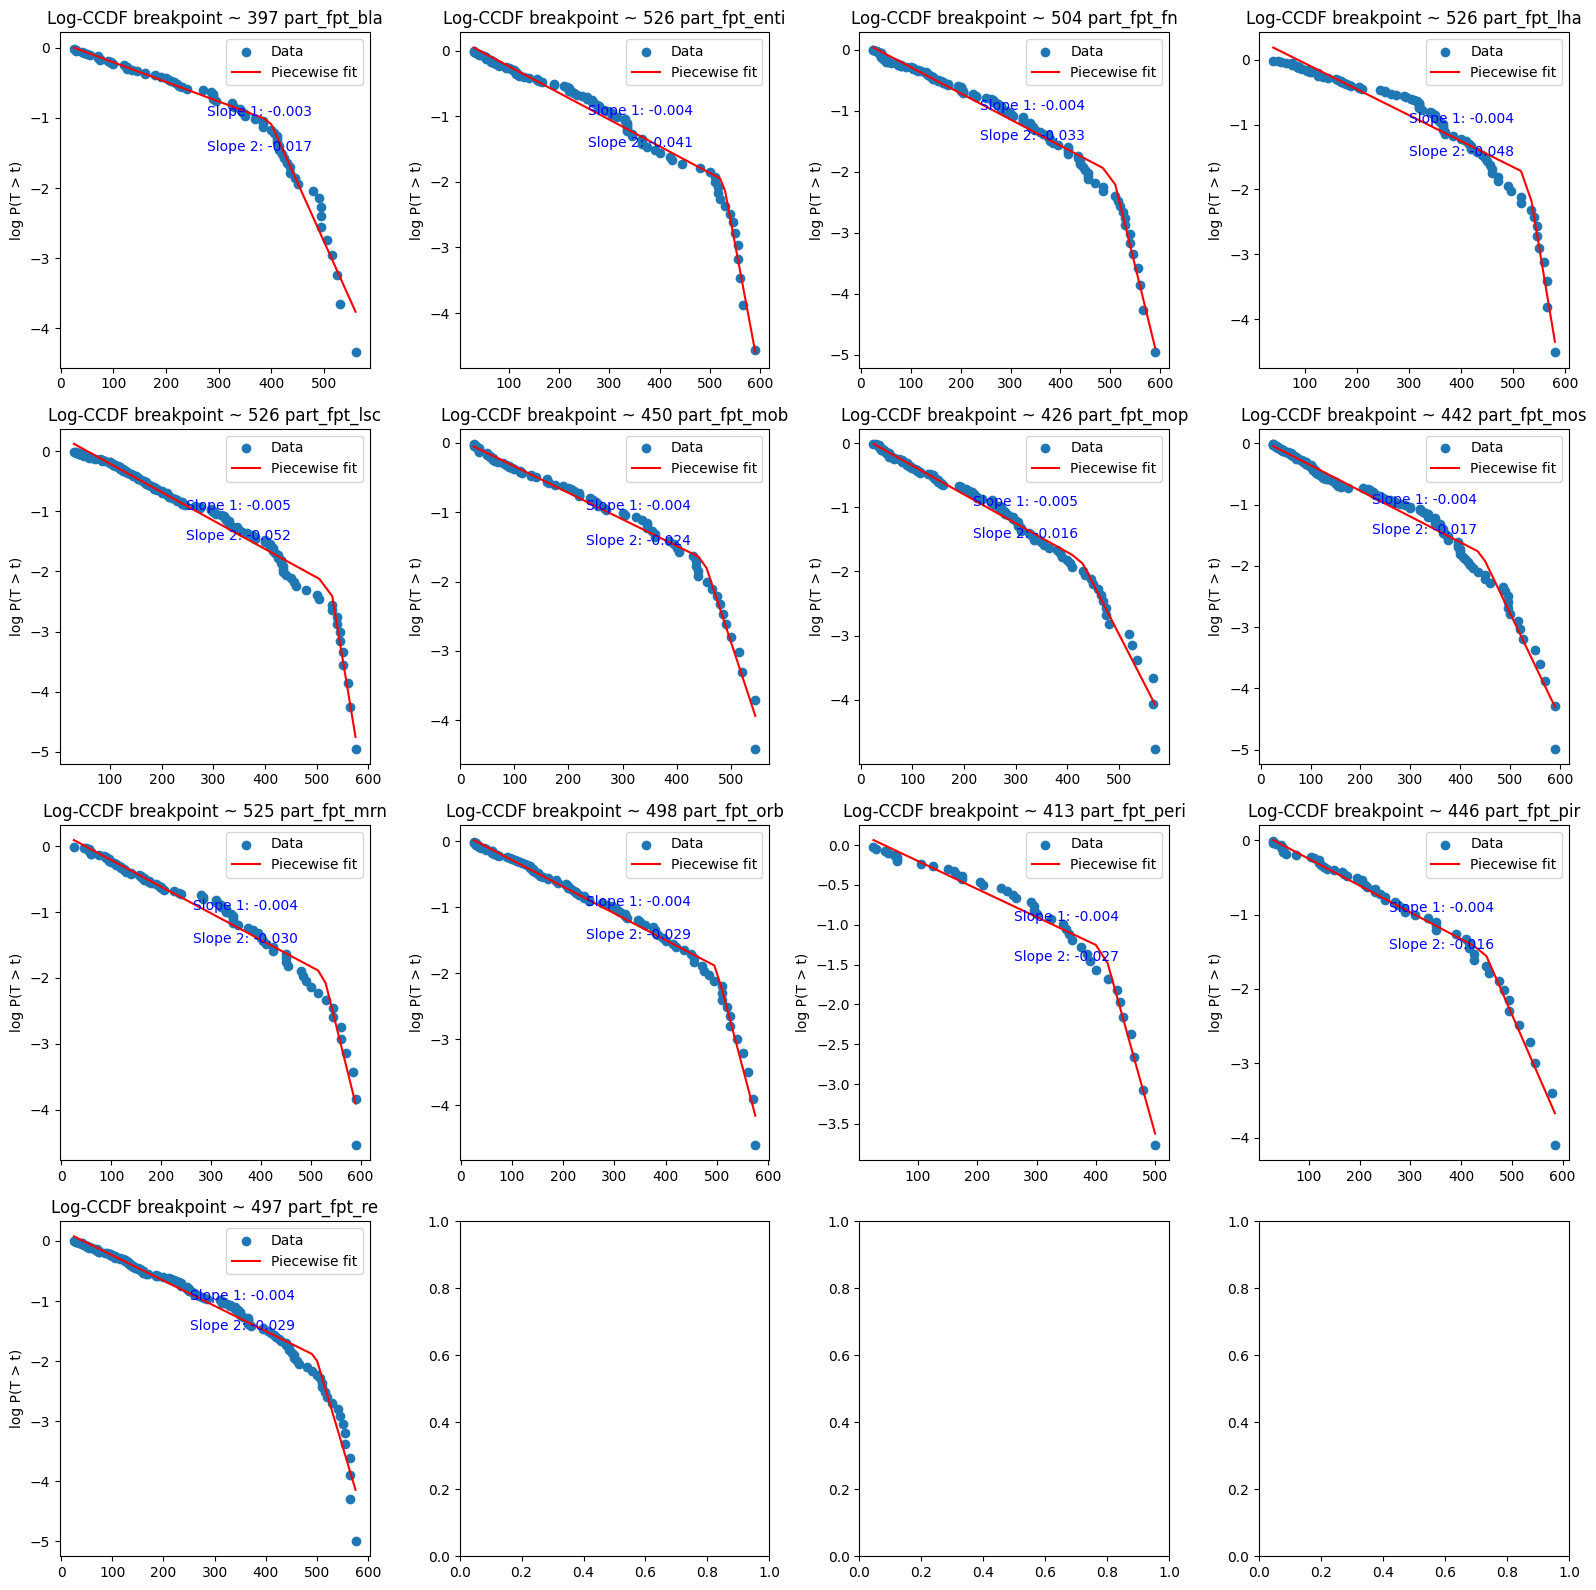

In [35]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp2 = {}
dict_joint = {}
dict_slp1_vals={}
# store standar error of early slopes
dict_slp1_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    part_fpt = [x for x in params[1]["fp_t"] if 20 < x < 600]

    p = fit_piecewiseLinear(part_fpt, ax, f"part_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['exp'][0]
    dict_exp2[nw] = p['exp'][1]
    dict_joint[nw] = p['joint']
    dict_slp1_vals[nw]=p['slope_1_entries']
    dict_slp1_se[nw]=p['s1_se']

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


In [17]:
dict_slp1_se

{'bla': 0.00013333688900138722,
 'enti': 7.654491970197502e-05,
 'fn': 6.27307344071776e-05,
 'lha': 0.00013386333616110816,
 'lsc': 6.773143533036703e-05,
 'mob': 7.896589684963015e-05,
 'mop': 8.26759787104747e-05,
 'mos': 7.911890178545498e-05,
 'mrn': 9.960984202194108e-05,
 'orb': 5.992592138328281e-05,
 'peri': 0.00015528715720235171,
 'pir': 9.548073859279774e-05,
 're': 8.168054151536047e-05}

Applying T test comparing every with FN

In [36]:
def compare_slopes(m1, se1, m2, se2):
    """
    Returns the t-statistic and p-value for the comparison of two slopes.
    """
    
    # Calculate the t-statistic
    t_stat = (m1 - m2) / np.sqrt(se1**2 + se2**2)
    
    # Calculate p-value (two-tailed)
    # Using normal distribution (Z-test) as a standard approximation for large N
    p_value = 2 * (1 - stats.norm.cdf(abs(t_stat)))
    
    return t_stat, p_value






In [37]:
nw=[]
for s,se,label in zip(list(dict_exp1.values()),list(dict_slp1_se.values()),dict_exp1.keys()):
    t, p = compare_slopes(dict_exp1['fn'], dict_slp1_se['fn'],s,se)
    print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

    # if p<0.05, then nw is significant
    if p<0.05:
        nw.append(label)
    else:
        pass

T-statistic: -10.1284, P-value: 0.0000
T-statistic: -2.2203, P-value: 0.0264
T-statistic: 0.0000, P-value: 1.0000
T-statistic: -1.9063, P-value: 0.0566
T-statistic: 4.8522, P-value: 0.0000
T-statistic: -4.5434, P-value: 0.0000
T-statistic: 2.1004, P-value: 0.0357
T-statistic: -0.9975, P-value: 0.3185
T-statistic: -2.1177, P-value: 0.0342
T-statistic: -2.8699, P-value: 0.0041
T-statistic: -4.6620, P-value: 0.0000
T-statistic: -6.0684, P-value: 0.0000
T-statistic: -0.7191, P-value: 0.4721


In [38]:
nw

['bla', 'enti', 'lsc', 'mob', 'mop', 'mrn', 'orb', 'peri', 'pir']

Storing above data for fig5j  

In [39]:
part_fpt={'slp1':dict_exp1,'bp':dict_joint,'s_nw':nw}
part_fpt

{'slp1': {'bla': -0.002796619610971979,
  'enti': -0.004069441841018009,
  'fn': -0.004289178276922395,
  'lha': -0.00400735575441655,
  'lsc': -0.004737129859902477,
  'mob': -0.0038309759431309365,
  'mop': -0.0045071543292842225,
  'mos': -0.00418845919078906,
  'mrn': -0.004039889247590005,
  'orb': -0.004040201034821221,
  'peri': -0.0035083772611709282,
  'pir': -0.0035958723000691657,
  're': -0.004215119180468677},
 'bp': {'bla': 397,
  'enti': 526,
  'fn': 504,
  'lha': 526,
  'lsc': 526,
  'mob': 450,
  'mop': 426,
  'mos': 442,
  'mrn': 525,
  'orb': 498,
  'peri': 413,
  'pir': 446,
  're': 497},
 's_nw': ['bla', 'enti', 'lsc', 'mob', 'mop', 'mrn', 'orb', 'peri', 'pir']}

### FPT full

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
Slopes of fitted lines: [-0.00172833 -0.01562133]
SE for early slopes 0.0006713606087754791
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
Slopes of fitted lines: [-0.0024811  -0.01187075]
SE for early slopes 0.00020441389318313723
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
Slopes of fitted lines: [-0.00348519 -0.02382408]
SE for early slopes 0.00015133312920680627
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
Slopes of fitted lines: [-0.00202074 -0.01663981]
SE for early slopes 0.00034301765981841197
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
Slopes of fitted lines: [-0.00243652 -0.0166002 ]
SE for early slopes 0.00023209367867947124
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
Slopes of fitted lines: [-0.00225944 -0.01565076]
SE for early slopes 0.00018363291241037567
Proce

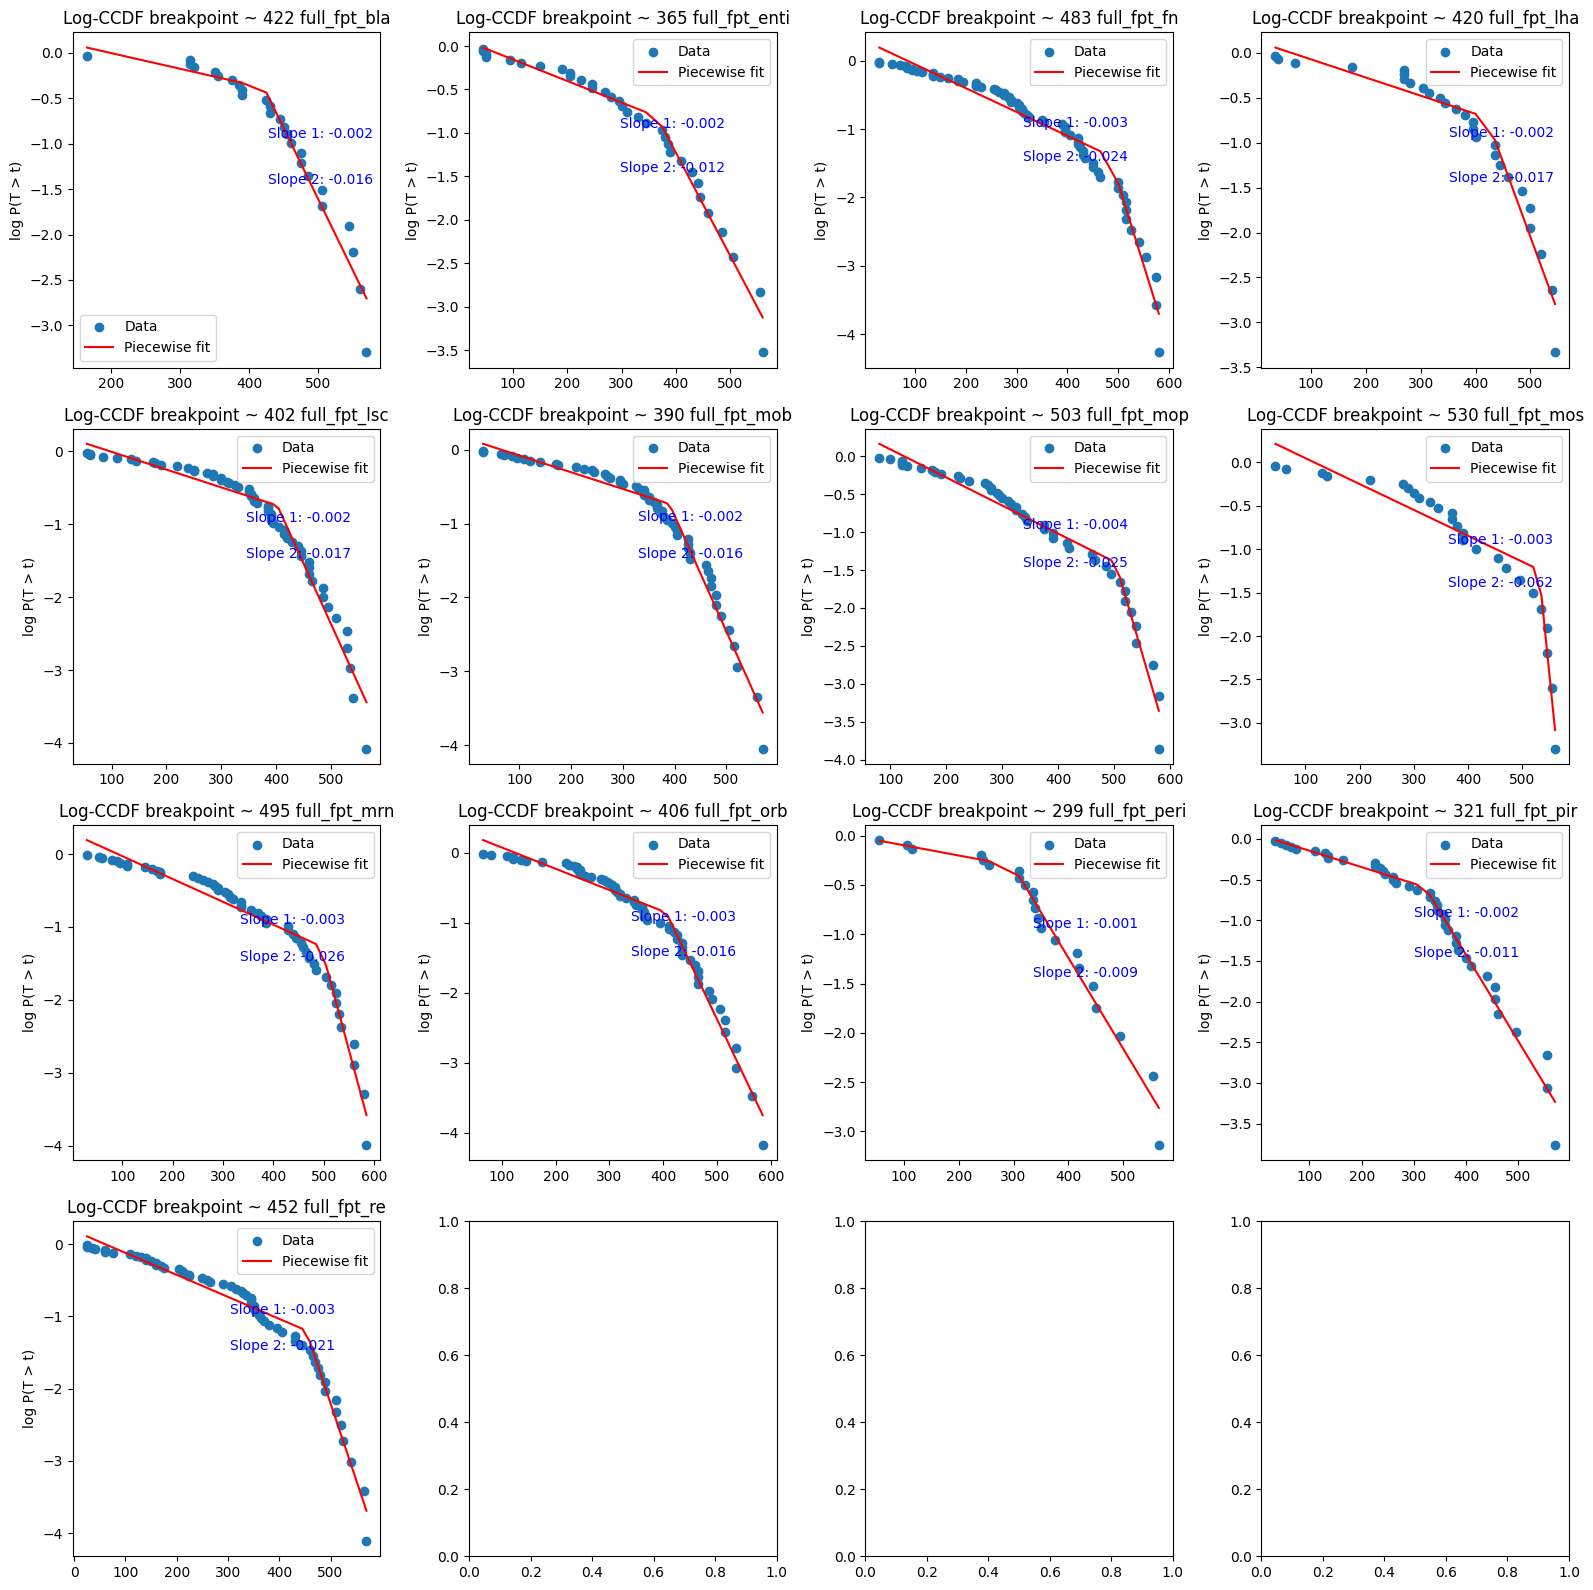

In [40]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp2 = {}
dict_joint = {}
dict_slp1_vals={}
# store standar error of early slopes
dict_slp1_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    full_fpt = [x for x in params[2]["fp_t"] if 20 < x < 600]

    p = fit_piecewiseLinear(full_fpt, ax, f"full_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['exp'][0]
    dict_exp2[nw] = p['exp'][1]
    dict_joint[nw] = p['joint']
    dict_slp1_vals[nw]=p['slope_1_entries']
    dict_slp1_se[nw]=p['s1_se']

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


t test

In [41]:
nw=[]
for s,se,label in zip(list(dict_exp1.values()),list(dict_slp1_se.values()),dict_exp1.keys()):
    t, p = compare_slopes(dict_exp1['fn'], dict_slp1_se['fn'],s,se)
    print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

    # if p<0.05, then nw is significant
    if p<0.05:
        nw.append(label)
    else:
        pass

T-statistic: -2.5528, P-value: 0.0107
T-statistic: -3.9479, P-value: 0.0001
T-statistic: 0.0000, P-value: 1.0000
T-statistic: -3.9061, P-value: 0.0001
T-statistic: -3.7848, P-value: 0.0002
T-statistic: -5.1512, P-value: 0.0000
T-statistic: 0.8863, P-value: 0.3754
T-statistic: -1.5428, P-value: 0.1229
T-statistic: -1.5726, P-value: 0.1158
T-statistic: -1.8273, P-value: 0.0677
T-statistic: -5.4124, P-value: 0.0000
T-statistic: -5.3106, P-value: 0.0000
T-statistic: -2.1692, P-value: 0.0301


Storing above for fig5j

In [42]:
full_fpt={'slp1':dict_exp1,'bp':dict_joint,'s_nw':nw}
full_fpt

{'slp1': {'bla': -0.0017283327790649319,
  'enti': -0.002481104647830243,
  'fn': -0.003485187146264445,
  'lha': -0.002020739726416017,
  'lsc': -0.0024365184952171636,
  'mob': -0.002259442646654004,
  'mop': -0.0036945290098614122,
  'mos': -0.0029857152327352936,
  'mrn': -0.003136017717760676,
  'orb': -0.0030428953227869615,
  'peri': -0.0010357434756623372,
  'pir': -0.002017500322079742,
  're': -0.003048292631597777},
 'bp': {'bla': 422,
  'enti': 365,
  'fn': 483,
  'lha': 420,
  'lsc': 402,
  'mob': 390,
  'mop': 503,
  'mos': 530,
  'mrn': 495,
  'orb': 406,
  'peri': 299,
  'pir': 321,
  're': 452},
 's_nw': ['bla', 'enti', 'lha', 'lsc', 'mob', 'peri', 'pir', 're']}

### Part ST

Processing file: ..\..\data\results\calculate_final_params\final_bla.pkl
Slopes of fitted lines: [-0.01861512 -0.00376398]
SE for early slopes 0.0001844238269921013
Processing file: ..\..\data\results\calculate_final_params\final_enti.pkl
Slopes of fitted lines: [-0.02865726 -0.0080804 ]
SE for early slopes 0.0004521408399212084
Processing file: ..\..\data\results\calculate_final_params\final_fn.pkl
Slopes of fitted lines: [-0.02424313 -0.01373869]
SE for early slopes 0.00025220591394754994
Processing file: ..\..\data\results\calculate_final_params\final_lha.pkl
Slopes of fitted lines: [-0.03244669 -0.00793549]
SE for early slopes 0.0005532935297359866
Processing file: ..\..\data\results\calculate_final_params\final_lsc.pkl
Slopes of fitted lines: [-0.0228427  -0.00791421]
SE for early slopes 0.0003978858401352809
Processing file: ..\..\data\results\calculate_final_params\final_mob.pkl
Slopes of fitted lines: [-0.02858149 -0.00603429]
SE for early slopes 0.0004357263025801548
Processin

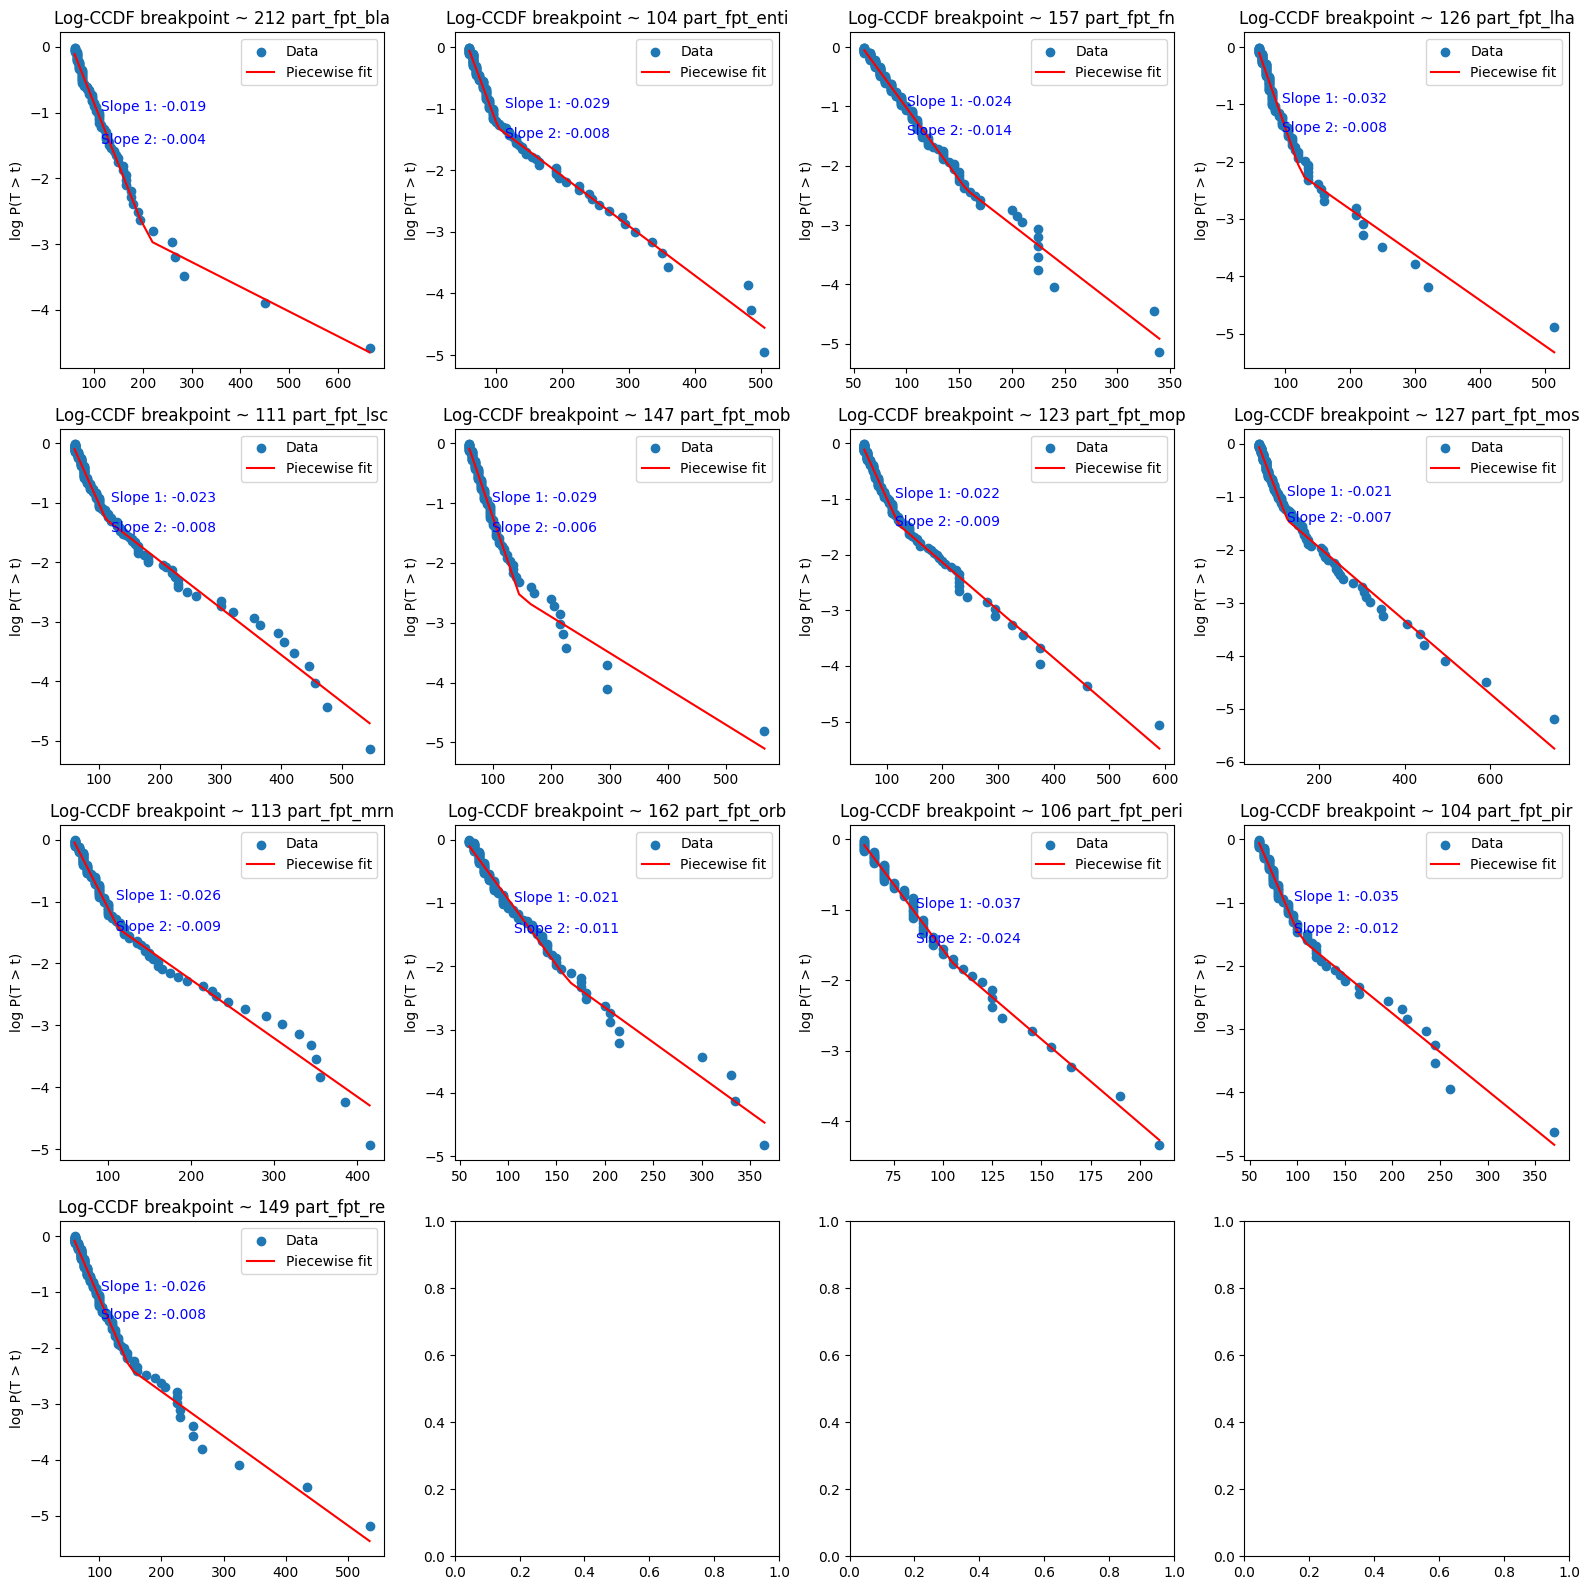

In [43]:
# Define grid size
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 16))

# Flatten axes for easy iteration
axes = axes.flatten()

# initialize as dicts instead of lists
dict_exp1 = {}
dict_exp2 = {}
dict_joint = {}
dict_slp1_vals={}
# store standar error of early slopes
dict_slp1_se={}

for ax, file in zip(axes, files):
    print(f'Processing file: {file}')
   
    with open(file, "rb") as f:
        params = pickle.load(f)

    part_st = [x for x in params[1]["s_t"] if 25 < x < 800]

    p = fit_piecewiseLinear(part_st, ax, f"part_fpt_{file.split('_')[-1].split('.')[-2]}")
    nw = file.split('_')[-1].split('.')[-2]

    # directly assign into dicts
    dict_exp1[nw] = p['exp'][0]
    dict_exp2[nw] = p['exp'][1]
    dict_joint[nw] = p['joint']
    dict_slp1_vals[nw]=p['slope_1_entries']
    dict_slp1_se[nw]=p['s1_se']

    

plt.tight_layout()
# plt.savefig('../../data/results/Part_FPT_fit.png', format='png')
plt.show()


T test on early slope part st

In [44]:
nw=[]
for s,se,label in zip(list(dict_exp1.values()),list(dict_slp1_se.values()),dict_exp1.keys()):
    t, p = compare_slopes(dict_exp1['fn'], dict_slp1_se['fn'],s,se)
    print(f"T-statistic: {t:.4f}, P-value: {p:.4f}")

    # if p<0.05, then nw is significant
    if p<0.05:
        nw.append(label)
    else:
        pass

T-statistic: -18.0130, P-value: 0.0000
T-statistic: 8.5260, P-value: 0.0000
T-statistic: 0.0000, P-value: 1.0000
T-statistic: 13.4913, P-value: 0.0000
T-statistic: -2.9728, P-value: 0.0030
T-statistic: 8.6172, P-value: 0.0000
T-statistic: -6.5305, P-value: 0.0000
T-statistic: -8.8829, P-value: 0.0000
T-statistic: 3.5568, P-value: 0.0004
T-statistic: -8.1558, P-value: 0.0000
T-statistic: 19.1716, P-value: 0.0000
T-statistic: 14.9947, P-value: 0.0000
T-statistic: 3.7198, P-value: 0.0002


Data for figure 5j

In [ ]:
part_st={'slp1':dict_exp1,'bp':dict_joint,'s_nw':nw}
part_st